In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import  train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error
from sklearn.pipeline import Pipeline

In [145]:
import warnings
warnings.filterwarnings('ignore')  # Suppresses all warnings
import seaborn as sns
sns.set_context('notebook')  # Sets font sizes and elements for notebook use
sns.set_style('white')       # Sets plot background and grid style


## Exploring and Understanding the Dataset

*In this lab, we will utilize the car sales dataset stored on IBM Cloud Object Storage. This dataset encompasses detailed automotive metadata, including manufacturer identifiers, model release year, a range of technical specifications, and the corresponding sale prices. Prior to analysis, the dataset underwent preprocessing in the Linear Regression Notebook, which involved data cleaning and feature transformation techniques—specifically, categorical encoding using one-hot encoding for nominal variables and label encoding for ordinal attributes.*

In [149]:
data=pd.read_csv("encoded_car_data.csv")
data

,diesel,gas,std,turbo,convertible,hardtop,hatchback,sedan,wagon,4wd,...,wheelbase,curbweight,enginesize,boreratio,horsepower,carlength,carwidth,citympg,highwaympg,price
0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,88.6,2548.0,130.0,3.47,111.0,168.8,64.1,21.0,27.0,13495.0
1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,88.6,2548.0,130.0,3.47,111.0,168.8,64.1,21.0,27.0,16500.0
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,94.5,2823.0,152.0,2.68,154.0,171.2,65.5,19.0,26.0,16500.0
3,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,99.8,2337.0,109.0,3.19,102.0,176.6,66.2,24.0,30.0,13950.0
4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,99.4,2824.0,136.0,3.19,115.0,176.6,66.4,18.0,22.0,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,109.1,2952.0,141.0,3.78,114.0,188.8,68.9,23.0,28.0,16845.0
201,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,109.1,3049.0,141.0,3.78,160.0,188.8,68.8,19.0,25.0,19045.0
202,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,109.1,3012.0,173.0,3.58,134.0,188.8,68.9,18.0,23.0,21485.0
203,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,109.1,3217.0,145.0,3.01,106.0,188.8,68.9,26.0,27.0,22470.0


The features and types using the info() method.

In [151]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 36 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   diesel       205 non-null    float64
 1   gas          205 non-null    float64
 2   std          205 non-null    float64
 3   turbo        205 non-null    float64
 4   convertible  205 non-null    float64
 5   hardtop      205 non-null    float64
 6   hatchback    205 non-null    float64
 7   sedan        205 non-null    float64
 8   wagon        205 non-null    float64
 9   4wd          205 non-null    float64
 10  fwd          205 non-null    float64
 11  rwd          205 non-null    float64
 12  dohc         205 non-null    float64
 13  dohcv        205 non-null    float64
 14  l            205 non-null    float64
 15  ohc          205 non-null    float64
 16  ohcf         205 non-null    float64
 17  ohcv         205 non-null    float64
 18  rotor        205 non-null    float64
 19  eight   

**We have a total of 36 features in our dataset after applying one-hot encoding.**

**Before diving into polynomial analysis, let's first visualize some relationships between these features and our target variable, 'price'.**

##  **sns.lmplot() does:**
**It performs linear regression automatically using statsmodels or scipy in the background and draws both:**

- The scatterplot of your data points, and

- The best-fit linear regression line (along with confidence intervals, if ci is set)

- order=2


        means:  Fit a polynomial regression of degree 2 (i.e., a quadratic curve).

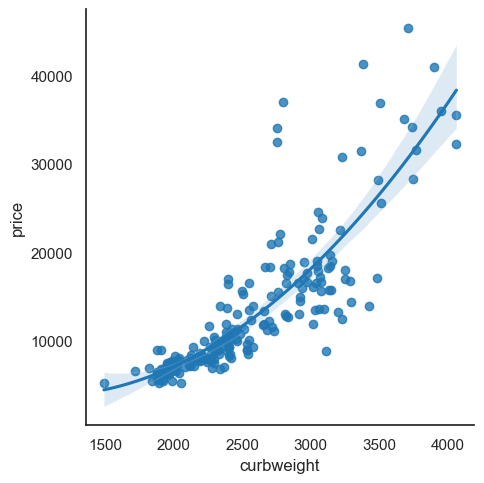

In [154]:
sns.lmplot(x = 'curbweight', y = 'price', data = data, order=2)

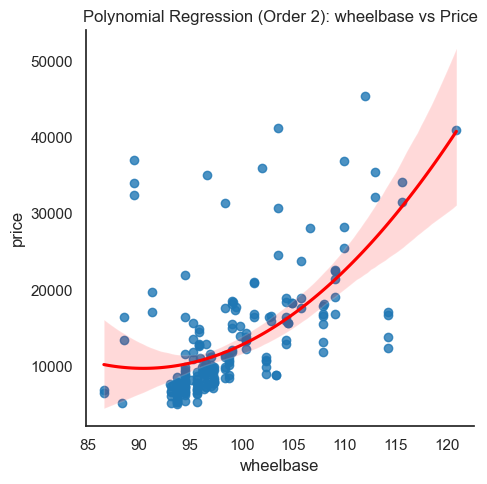

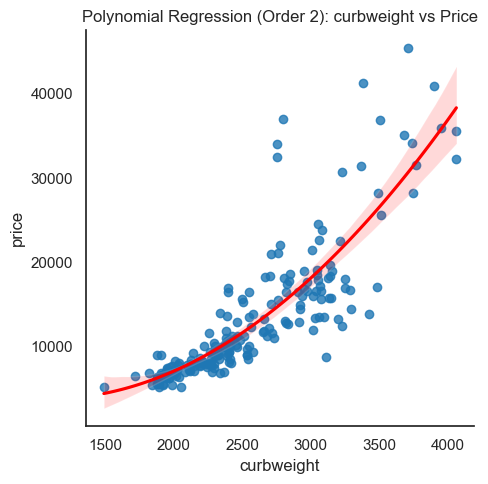

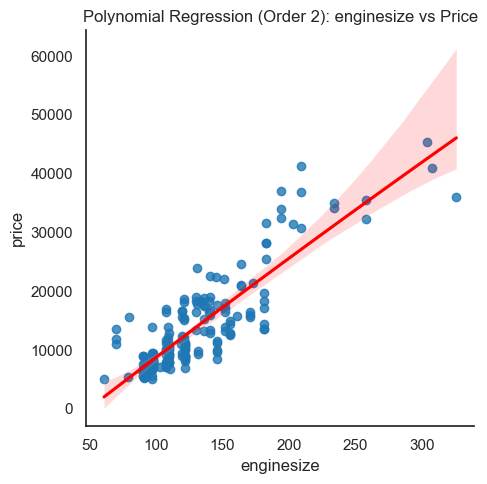

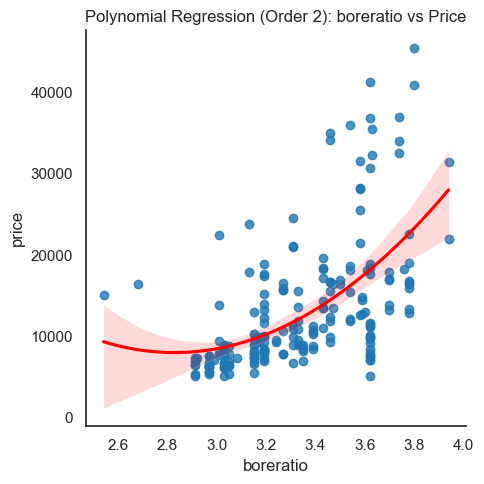

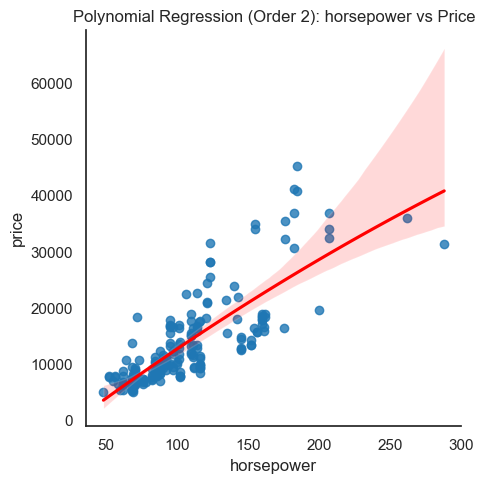

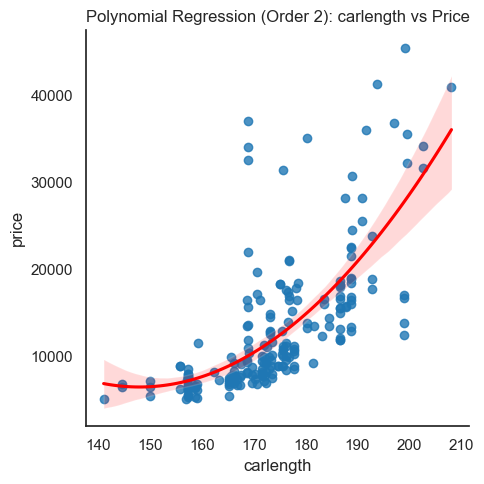

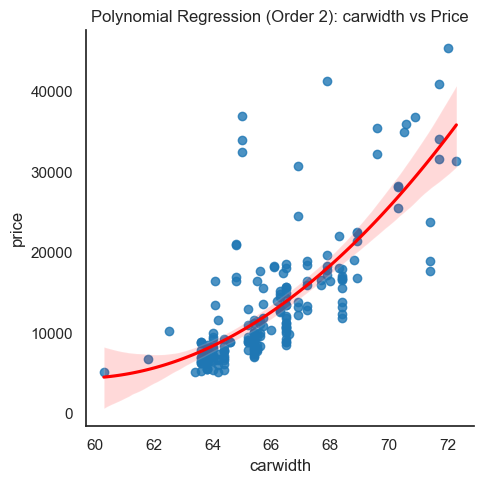

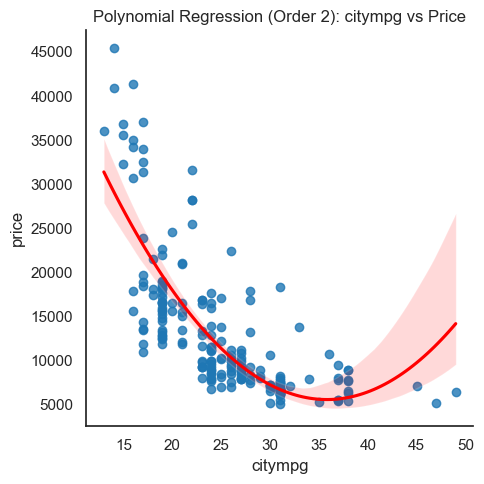

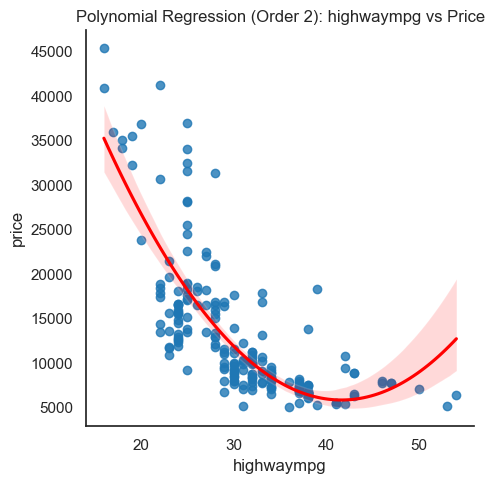

In [155]:
# Only select features with more than a few unique values (e.g., > 10)
continuous_features = [col for col in data.columns if col != 'price' and data[col].nunique() > 10]

for feature in continuous_features:
    try:
        sns.lmplot(x=feature, y='price', data=data, order=2, line_kws={'color': 'red'})
        plt.title(f'Polynomial Regression (Order 2): {feature} vs Price')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Skipping feature '{feature}' due to error: {e}")


## **Data Preparation**
**Let's first split our data into X features and y targe**

In [157]:
X=data.drop(columns="price",axis=1)
y=data["price"]
X,y

(     diesel  gas  std  turbo  convertible  hardtop  hatchback  sedan  wagon  \
 0       0.0  1.0  1.0    0.0          1.0      0.0        0.0    0.0    0.0   
 1       0.0  1.0  1.0    0.0          1.0      0.0        0.0    0.0    0.0   
 2       0.0  1.0  1.0    0.0          0.0      0.0        1.0    0.0    0.0   
 3       0.0  1.0  1.0    0.0          0.0      0.0        0.0    1.0    0.0   
 4       0.0  1.0  1.0    0.0          0.0      0.0        0.0    1.0    0.0   
 ..      ...  ...  ...    ...          ...      ...        ...    ...    ...   
 200     0.0  1.0  1.0    0.0          0.0      0.0        0.0    1.0    0.0   
 201     0.0  1.0  0.0    1.0          0.0      0.0        0.0    1.0    0.0   
 202     0.0  1.0  1.0    0.0          0.0      0.0        0.0    1.0    0.0   
 203     1.0  0.0  0.0    1.0          0.0      0.0        0.0    1.0    0.0   
 204     0.0  1.0  0.0    1.0          0.0      0.0        0.0    1.0    0.0   
 
      4wd  ...  two  wheelbase  curbwe

## Train Test Split
*Now that we have divided our data into training and testing sets, the training set is used to help the model learn patterns and relationships based on defined criteria, while the testing set is reserved for evaluating the model's performance on unseen data to assess its generalization ability.*

In [164]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)
print("Number of test samples:", X_test.shape[0])
print("Number of training samples:", X_train.shape[0])

Number of test samples: 62
Number of training samples: 143


In [168]:
LR=LinearRegression()
LR.fit(X_train,y_train)
predict=LR.predict(X_test)

**Why is it not r2_score(y_pred, y_true)?**

Because the definition of R² is based on comparing the actual (true) values against what the model predicts

In [170]:
print("R^2 on training  data ",LR.score(X_train, y_train))
print("R^2 on testing data ",LR.score(X_test,y_test))
print("R^2 on testing data ",r2_score(y_test,predict))

R^2 on training  data  0.9260523623060208
R^2 on testing data  0.8488489221292775
R^2 on testing data  0.8488489221292775


***We can visualize the distribution of predicted values in comparison to the actual target values.***

*distplot` is a deprecated function and will be removed in seaborn v0.14.0.*  
- so, use fun plot_his(y, yhat)

In [174]:
def  plot_dis(y,yhat):
    
    plt.figure()
    ax1 = sns.distplot(y, hist=False, color="r", label="Actual Value")
    sns.distplot(yhat, hist=False, color="b", label="Fitted Values" , ax=ax1)
    plt.legend()

    plt.title('Actual vs Fitted Values')
    plt.xlabel('Price (in dollars)')
    plt.ylabel('Proportion of Cars')

    plt.show()
    plt.close()

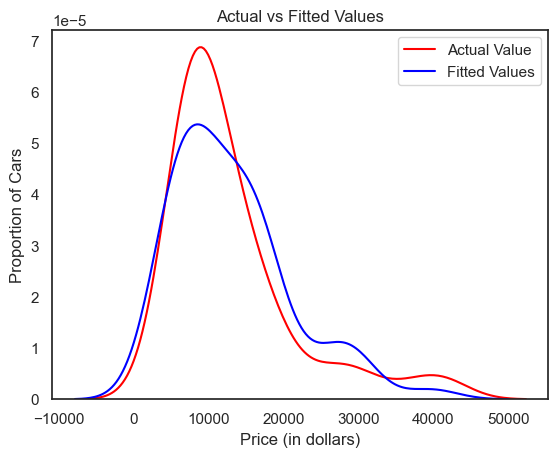

In [176]:
plot_dis(y_test,predict)

In [177]:
def plot_his(y, yhat):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    # Subplot 1: Histogram 
    sns.histplot(y, color="r", bins=30, element="poly", fill=False, ax=ax[0],label="Actual Value")
    sns.histplot(yhat, color="b", bins=30, element="poly", fill=False, ax=ax[0],label="Fitted Values")
    ax[0].set_title('Histogram')
    ax[0].set_xlabel('Price (in dollars)')
    ax[0].set_ylabel('Density')
    ax[0].legend()

    #  Subplot 2: Line-only KDE
    sns.kdeplot(y, color="r", linewidth=2, ax=ax[1],label="Actual Value")
    sns.kdeplot(yhat, color="b", linewidth=2, ax=ax[1],label="Fitted Values")
    ax[1].set_title('KDE ')
    ax[1].set_xlabel('Price (in dollars)')
    ax[1].set_ylabel('Density')
    ax[1].legend()

    fig.suptitle("Actual vs Fitted Values")
    plt.tight_layout()
    plt.show()
    plt.close()


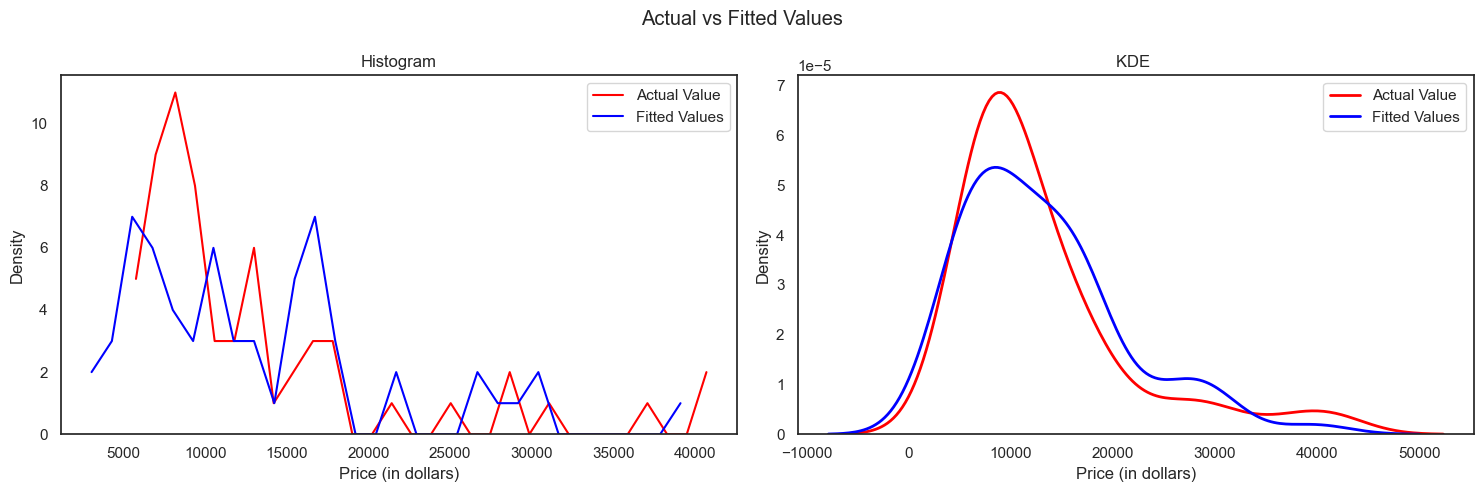

In [180]:
plot_his(y_test,predict)

**Now** we will view the estimated coefficients for the linear regression problem

In [182]:
{col:coef for col,coef in zip(X.columns, LR.coef_)}

{'diesel': 831913222608671.2,
 'gas': 831913222607230.4,
 'std': 265.817138671875,
 'turbo': -264.91015625,
 'convertible': 1772.9595489501953,
 'hardtop': 3023.3792724609375,
 'hatchback': -1723.89794921875,
 'sedan': -619.0015869140625,
 'wagon': -2452.8715209960938,
 '4wd': -568.2215728759766,
 'fwd': -232.0255126953125,
 'rwd': 855.8648681640625,
 'dohc': 2472.438751220703,
 'dohcv': -13345.657196044922,
 'l': 2227.9989013671875,
 'ohc': 4688.209747314453,
 'ohcf': 6033.189788818359,
 'ohcv': -2810.8487548828125,
 'rotor': 726.4886322021484,
 'eight': 9304.24674987793,
 'five': -2735.461212158203,
 'four': -5352.745178222656,
 'six': -2151.5219116210938,
 'three': 0.0,
 'twelve': 208.89024353027344,
 'two': 726.4573822021484,
 'wheelbase': 77.236328125,
 'curbweight': 5.125,
 'enginesize': 23.912109375,
 'boreratio': -1786.1702728271484,
 'horsepower': 69.234375,
 'carlength': -63.23828125,
 'carwidth': 575.81005859375,
 'citympg': -161.779296875,
 'highwaympg': 145.765625}

**Some values (like for 'diesel' and 'gas') are extremely large (~8e14), which is unusual.**
- 'diesel': 831913222608671.2,
- 'gas': 831913222607230.4,

**This problem is called:**
- "Perfect Multicollinearity" (or "Dummy Variable Trap")

**Rule for One-Hot Encoding:**
- If your original categorical feature has N unique categories, then:
- One-hot encoding creates N new binary columns
- You should drop 1 column, leaving N − 1 columns
- we drop one dummy column to avoid multicollinearity
- This is called avoiding the dummy variable trap

**The function below will calculate the  R² on each feature given the a input model.**

In [189]:
def get_R2_features(model,test=True): 
    features=list(X)
    features.remove("three") ## 'three': 0.0, estimated coefficients
    
    R_2_train=[]
    R_2_test=[]

    for feature in features:
        model.fit(X_train[[feature]],y_train)
        
        R_2_test.append(model.score(X_test[[feature]],y_test))
        R_2_train.append(model.score(X_train[[feature]],y_train))
        
    plt.bar(features,R_2_train,label="Train")
    plt.bar(features,R_2_test,label="Test")
    plt.xticks(rotation=90)
    plt.ylabel("$R^2$")
    plt.legend()
    plt.show()
    print("Training R^2 mean value {} Testing R^2 mean value {} ".format(str(np.mean(R_2_train)),str(np.mean(R_2_test))) )
    print("Training R^2 max value {} Testing R^2 max value {} ".format(str(np.max(R_2_train)),str(np.max(R_2_test))) )

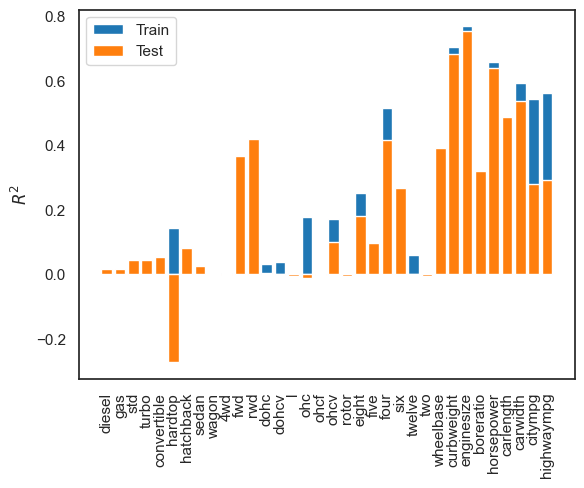

Training R^2 mean value 0.21817773426877915 Testing R^2 mean value 0.18241493035139267 
Training R^2 max value 0.7686929078033781 Testing R^2 max value 0.7534902447506853 


In [191]:
get_R2_features(LR)

## What Does the Plot Tell You
**From the image:**
- Each bar shows how well a **single feature alone predicts the target**.
- Blue bars **(train)** and orange bars **(test)** vary — showing overfitting or underfitting.
- Features like **"curb weight", "engine size",** and **"horsepower"** have high R² → they are strong predictors.
- Negative or very low R² **(e.g., for "gas", "diesel")** means those features are not helpful alone.

*From the plot, we observe that some individual features perform nearly as well as the full model (excluding feature 'three'). Interestingly, features with smaller estimated coefficients in the full model tend to have higher individual R² values, suggesting they generalize better. In contrast, features with larger coefficients may indicate overfitting, as their performance drops significantly on the test set*